# 数据分析领域主要的支柱

1. **数据预处理（Data Preprocessing）**：
   - **数据清洗**：处理缺失值、重复值和异常值，确保数据质量。
   - **数据转换**：标准化、归一化和编码等，使数据适合分析和建模。
   - **特征工程**：从原始数据中提取有用的特征，以提高模型性能。


2. **数据聚合（Data Aggregation）**：
   - **汇总统计**：计算如均值、总和、最大值、最小值等统计量，以便从原始数据中提取有意义的信息。
   - **分组操作**：将数据按某些关键字段进行分组，并对分组后的数据进行计算和分析。

3. **数据建模（Data Modeling）**：
   - **机器学习模型**：使用算法如回归、分类、聚类等来创建预测模型。
   - **统计建模**：使用统计方法如线性回归、时间序列分析等来理解和预测数据。

4. **数据汇总（Data Summarization）**：
   - **报告生成**：创建详细的分析报告，概述关键发现和结论。
   - **摘要统计**：使用描述性统计量如平均值、中位数、方差等来总结数据的主要特征。

5. **数据可视化（Data Visualization）**：
   - **图表与图形**：使用柱状图、折线图、散点图、热图等来直观展示数据。
   - **仪表盘**：创建综合的可视化仪表盘，以便实时监控和分析数据。

这些支柱共同构成了数据分析的核心流程，从原始数据的准备到最终结果的展示和解释，每一步都至关重要。

# 可视化动机

> 一张图片的最大价值在于，它迫使我们注意到我们从未期望看到的东西。——John Tukey  
> 约翰·图基（John Tukey）是一位著名的统计学家和数据分析领域的先驱，他强调了图像和可视化在揭示数据中隐藏模式和意外发现方面的重要性。通过图像，我们可以更直观地理解数据的复杂性和深层次信息。


需要了解的内容：
+ 数据分析和可视化的框架，包括 pandas、matplotlib、seaborn、plotly 和 bokeh
+ 用数据制作精美而有意义的可视化文件，那么需要了解 D3.js（https://d3js.org/）

# 可视化案例

In [89]:
import seaborn as sns

from pyecharts.charts import Parallel
from pyecharts.charts import Scatter3D
from pyecharts.commons.utils import JsCode
from pyecharts import options as opts

from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

## [具体数据](https://archive.ics.uci.edu/dataset/186/wine+quality)

+ fixed acidity: 固定酸度, 代表酒中存在的非挥发性酸（如酒石酸）的量，通常以克每升（g/L）表示。
+ volatile acidity: 挥发酸度, 代表酒中挥发性酸（如醋酸）的量，通常以克每升（g/L）表示。较高的挥发酸度可能会影响酒的味道。
+ citric acid: 柠檬酸, 代表酒中柠檬酸的含量，通常以克每升（g/L）表示。柠檬酸能够增加酒的清新感。
+ residual sugar: 残糖, 酒中未发酵的糖分，通常以克每升（g/L）表示。残糖的量对酒的甜度有直接影响。
+ chlorides: 氯化物, 酒中氯化物的含量，通常以克每升（g/L）表示。高氯化物含量可能会影响酒的味道。
+ free sulfur dioxide: 游离二氧化硫, 代表酒中游离的二氧化硫的量，通常以毫克每升（mg/L）表示。二氧化硫可以防止氧化和细菌生长。
+ total sulfur dioxide: 总二氧化硫, 包括游离和结合形态的二氧化硫，通常以毫克每升（mg/L）表示。
+ density: 密度, 酒的密度，通常以克每毫升（g/mL）表示。密度可以与酒的糖分和酒精含量相关联。
+ pH: pH值, 酒的酸碱度，数值范围通常在0到14之间，影响酒的风味和稳定性。
+ sulphates: 硫酸盐, 酒中硫酸盐的含量，通常以克每升（g/L）表示。硫酸盐会影响酒的味道和口感。
+ alcohol: 酒精度, 酒精的含量，通常以百分比（%）表示。酒精度影响酒的口感和效果。
+ quality: 质量评分,酒的质量评分，通常在1到10之间。这个评分是针对酒的整体质量进行的主观评估。

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
wines = wine_quality.data.original

# metadata
metadata = wine_quality.metadata

# variable information
variables = wine_quality.variables

variables
wines

,name,role,type,demographic,description,units,missing_values
0,fixed_acidity,Feature,Continuous,None,None,None,no
1,volatile_acidity,Feature,Continuous,None,None,None,no
2,citric_acid,Feature,Continuous,None,None,None,no
3,residual_sugar,Feature,Continuous,None,None,None,no
4,chlorides,Feature,Continuous,None,None,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,None,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,None,None,no
7,density,Feature,Continuous,None,None,None,no
8,pH,Feature,Continuous,None,None,None,no
9,sulphates,Feature,Continuous,None,None,None,no


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [3]:
# quality label
# wines_copy = wines.copy()
wines['quality_label'] = pd.cut(wines['quality'], bins=(0, 5, 7, 10), right=True, labels=('low', 'medium', 'high'))
wines.groupby('color').describe(include='all').stack(level=0, future_stack=True)

count unique     top  freq        mean  \
color                                                                 
red   fixed_acidity         1599.0    NaN     NaN   NaN    8.319637   
      volatile_acidity      1599.0    NaN     NaN   NaN    0.527821   
      citric_acid           1599.0    NaN     NaN   NaN    0.270976   
      residual_sugar        1599.0    NaN     NaN   NaN    2.538806   
      chlorides             1599.0    NaN     NaN   NaN    0.087467   
      free_sulfur_dioxide   1599.0    NaN     NaN   NaN   15.874922   
      total_sulfur_dioxide  1599.0    NaN     NaN   NaN   46.467792   
      density               1599.0    NaN     NaN   NaN    0.996747   
      pH                    1599.0    NaN     NaN   NaN    3.311113   
      sulphates             1599.0    NaN     NaN   NaN    0.658149   
      alcohol               1599.0    NaN     NaN   NaN   10.422983   
      quality               1599.0    NaN     NaN   NaN    5.636023   
      quality_label           1599      3  medium   837         NaN   
white fixed_acidity         4898.0    NaN     NaN   NaN    6.854788   
      volatile_acidity      4898.0    NaN     NaN   NaN    0.278241   
      citric_acid           4898.0    NaN     NaN   NaN    0.334192   
      residual_sugar        4898.0    NaN     NaN   NaN    6.391415   
      chlorides             4898.0    NaN     NaN   NaN    0.045772   
      free_sulfur_dioxide   4898.0    NaN     NaN   NaN   35.308085   
      total_sulfur_dioxide  4898.0    NaN     NaN   NaN  138.360657   
      density               4898.0    NaN     NaN   NaN    0.994027   
      pH                    4898.0    NaN     NaN   NaN    3.188267   
      sulphates             4898.0    NaN     NaN   NaN    0.489847   
      alcohol               4898.0    NaN     NaN   NaN   10.514267   
      quality               4898.0    NaN     NaN   NaN    5.877909   
      quality_label           4898      3  medium  3078         NaN   

                                  std      min       25%      50%       75%  \
color                                                                         
red   fixed_acidity          1.741096      4.6       7.1      7.9       9.2   
      volatile_acidity        0.17906     0.12      0.39     0.52      0.64   
      citric_acid            0.194801      0.0      0.09     0.26      0.42   
      residual_sugar         1.409928      0.9       1.9      2.2       2.6   
      chlorides              0.047065    0.012      0.07    0.079      0.09   
      free_sulfur_dioxide   10.460157      1.0       7.0     14.0      21.0   
      total_sulfur_dioxide  32.895324      6.0      22.0     38.0      62.0   
      density                0.001887  0.99007    0.9956  0.99675  0.997835   
      pH                     0.154386     2.74      3.21     3.31       3.4   
      sulphates              0.169507     0.33      0.55     0.62      0.73   
      alcohol                1.065668      8.4       9.5     10.2      11.1   
      quality                0.807569      3.0       5.0      6.0       6.0   
      quality_label               NaN      NaN       NaN      NaN       NaN   
white fixed_acidity          0.843868      3.8       6.3      6.8       7.3   
      volatile_acidity       0.100795     0.08      0.21     0.26      0.32   
      citric_acid             0.12102      0.0      0.27     0.32      0.39   
      residual_sugar         5.072058      0.6       1.7      5.2       9.9   
      chlorides              0.021848    0.009     0.036    0.043      0.05   
      free_sulfur_dioxide   17.007137      2.0      23.0     34.0      46.0   
      total_sulfur_dioxide  42.498065      9.0     108.0    134.0     167.0   
      density                0.002991  0.98711  0.991723  0.99374    0.9961   
      pH                     0.151001     2.72      3.09     3.18      3.28   
      sulphates              0.114126     0.22      0.41     0.47      0.55   
      alcohol                1.230621      8.0       9.5     10.4

## 一维数据（1-D）

### 多维度指标

array([[<Axes: title={'center': 'fixed_acidity'}>,
        <Axes: title={'center': 'volatile_acidity'}>,
        <Axes: title={'center': 'citric_acid'}>],
       [<Axes: title={'center': 'residual_sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free_sulfur_dioxide'}>],
       [<Axes: title={'center': 'total_sulfur_dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

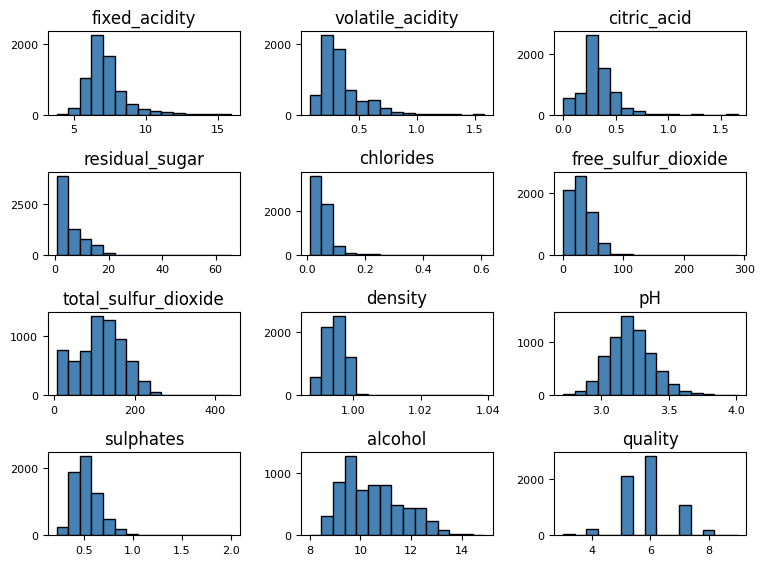

In [4]:
wines.hist(bins=15, color='steelblue', edgecolor='black', linewidth=1.0,
           xlabelsize=8, ylabelsize=8, grid=False)
plt.tight_layout(rect=(0, 0, 1.2, 1.2))

### 单维度指标

(array([ 232., 1879., 2363., 1250.,  496.,  176.,   52.,   22.,   13.,
           6.,    0.,    4.,    0.,    0.,    4.]),
 array([0.22      , 0.33866667, 0.45733333, 0.576     , 0.69466667,
        0.81333333, 0.932     , 1.05066667, 1.16933333, 1.288     ,
        1.40666667, 1.52533333, 1.644     , 1.76266667, 1.88133333,
        2.        ]),
 <BarContainer object of 15 artists>)

<Axes: xlabel='sulphates', ylabel='Density'>

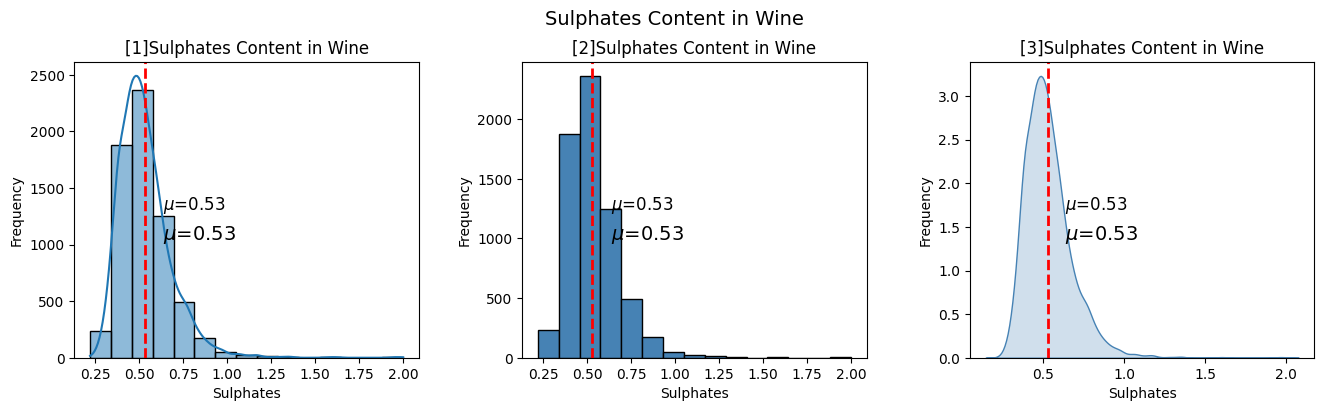

In [5]:
def add_text(ax, title: str, smean: float):
    ax.set_title(title)
    ax.set_xlabel("Sulphates")
    ax.set_ylabel("Frequency")

    text = r'$\mu$='+str(smean)
    ax.axvline(x=smean, color='red', linestyle='--', linewidth=2)
    ymin, ymax = ax.get_ylim()
    ax.text(smean * 1.2, ymax / 2, text, fontsize=12)
    ax.annotate(text, (smean * 1.2, ymax / 2.5), fontsize=14)
    return ax

fig = plt.figure(figsize = (16,4))
title = fig.suptitle("Sulphates Content in Wine", fontsize=14)
fig.subplots_adjust(top=0.85, wspace=0.3)

smean = round(wines['sulphates'].mean(),2)

# 图1
ax1 = fig.add_subplot(1, 3, 1)
ax1 = sns.histplot(wines, x='sulphates', bins=15, kde=True, ax=ax1,
                 # stat="percent",
                 )
title = '[1]Sulphates Content in Wine'
ax1 = add_text(ax1, title, smean)


# 图2
# Histogram
ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(wines['sulphates'], color='steelblue', bins=15, edgecolor='black', linewidth=1)  # return freq, bins, patches

title = '[2]Sulphates Content in Wine'
ax2 = add_text(ax2, title, smean)

# 图3

# Density Plot
ax3 = fig.add_subplot(1, 3, 3)
sns.kdeplot(wines['sulphates'], ax=ax3, fill=True, color='steelblue')

title = '[3]Sulphates Content in Wine'
ax3 = add_text(ax3, title, smean)

(array([ 232., 1879., 2363., 1250.,  496.,  176.,   52.,   22.,   13.,
           6.,    0.,    4.,    0.,    0.,    4.]),
 array([0.22      , 0.33866667, 0.45733333, 0.576     , 0.69466667,
        0.81333333, 0.932     , 1.05066667, 1.16933333, 1.288     ,
        1.40666667, 1.52533333, 1.644     , 1.76266667, 1.88133333,
        2.        ]),
 <BarContainer object of 15 artists>)

<Axes: xlabel='sulphates', ylabel='Density'>

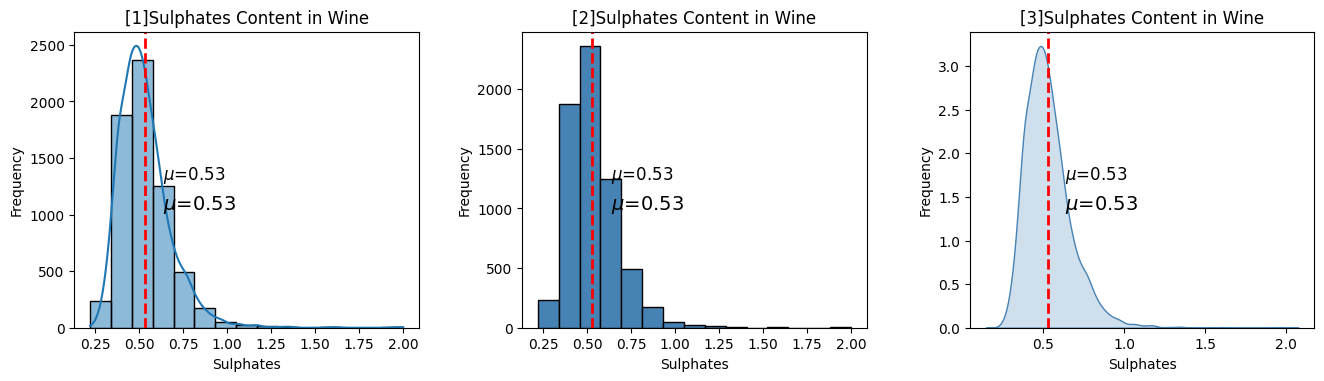

In [6]:
# 第二种方法

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.subplots_adjust(top=0.85, wspace=0.3)

smean = round(wines['sulphates'].mean(),2)

# 图1
ax1 = axes[0]
ax1 = sns.histplot(wines, x='sulphates', bins=15, kde=True, ax=ax1,
                 # stat="percent",
                 )
title = '[1]Sulphates Content in Wine'
ax1 = add_text(ax1, title, smean)


# 图2
# Histogram
ax2 = axes[1]
ax2.hist(wines['sulphates'], color='steelblue', bins=15, edgecolor='black', linewidth=1)  # return freq, bins, patches

title = '[2]Sulphates Content in Wine'
ax2 = add_text(ax2, title, smean)

# 图3

# Density Plot
ax3 = axes[2]
sns.kdeplot(wines['sulphates'], ax=ax3, fill=True, color='steelblue')

title = '[3]Sulphates Content in Wine'
ax3 = add_text(ax3, title, smean)

## 二维数据（2-D）

### 相关图

Text(0.5, 0.98, 'Wine Attributes Correlation Heatmap')

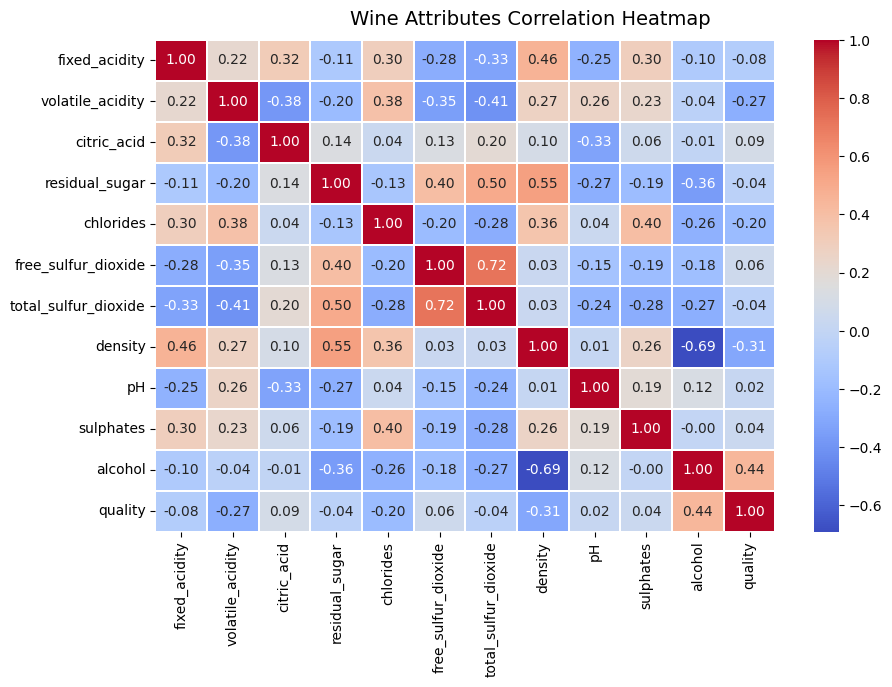

In [7]:
# Correlation Matrix Heatmap
fig, axes = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(top=0.93)

corr = wines.corr(numeric_only=True)
hm = sns.heatmap(round(corr, 2), annot=True, ax=axes, cmap="coolwarm", fmt='.2f',
                 linewidths=.05)

fig.suptitle('Wine Attributes Correlation Heatmap', fontsize=14)

### 配对散点图

Text(0.5, 1.02, 'Pairplot of Wine Characteristics')

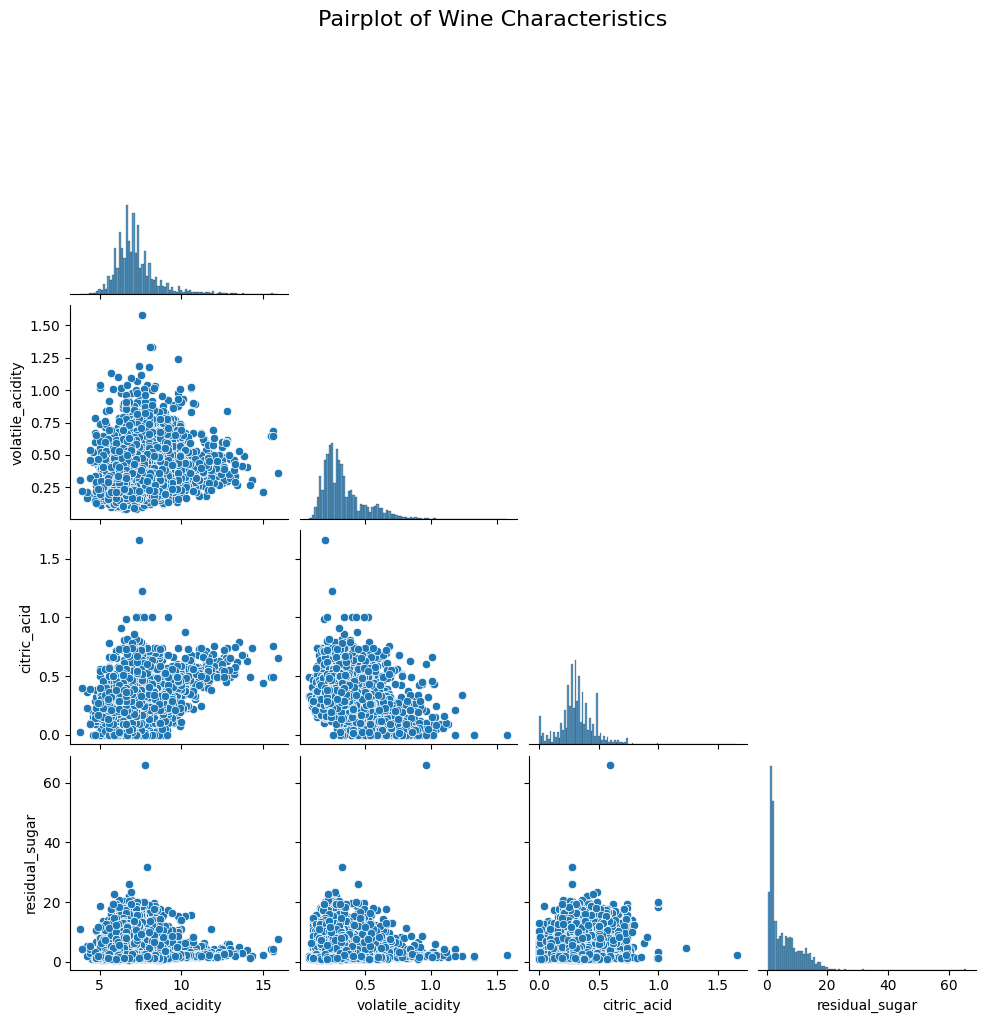

In [8]:
columns = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'color']
pairplot = sns.pairplot(wines[columns], 
                        # hue='color', 
                        # kind='hist',
                        corner=True)
pairplot.fig.subplots_adjust(top=0.95)  # 调整图表与标题的间距
plt.suptitle("Pairplot of Wine Characteristics", y=1.02, fontsize=16)

### 并行坐标图

In [9]:
columns = ['density', 'residual_sugar', 'total_sulfur_dioxide', 'fixed_acidity', 'color']
_wines_s = wines[columns].sample(100)

# 提取数值数据和分类数据
dims = [
    {"dim": 0, "name": "density", "min": _wines_s['density'].min(), "max": _wines_s['density'].max()},
    {"dim": 1, "name": "residual_sugar", "min": _wines_s['residual_sugar'].min(), "max": _wines_s['residual_sugar'].max()},
    {"dim": 2, "name": "total_sulfur_dioxide", "min": _wines_s['total_sulfur_dioxide'].min(), "max": _wines_s['total_sulfur_dioxide'].max()},
    {"dim": 3, "name": "fixed_acidity", "min": _wines_s['fixed_acidity'].min(), "max": _wines_s['fixed_acidity'].max()},
]

# 颜色映射逻辑：根据 'color' 字段值映射到不同的颜色
def get_line_style(color):
    if color == "red":
        return opts.LineStyleOpts(color="red", width=2)
    elif color == "white":
        return opts.LineStyleOpts(color="orange", width=2)
    else:
        return opts.LineStyleOpts(color="gray", width=2)

# 创建 Parallel 对象
parallel = Parallel(init_opts=opts.InitOpts(width="800px", height="500px"))

# 添加坐标轴 schema
parallel.add_schema(schema=dims)

for color in _wines_s['color'].unique():
    c_wines = _wines_s[_wines_s.color == color]
    p = parallel.add(
            series_name=color,  # 使用 color 字段作为系列名称
            data=c_wines.values.tolist(),  # 去掉最后的 color 字段，只保留数据
            linestyle_opts=get_line_style(color),  # 动态设置颜色
            inactive_opacity=0.1,  # 非激活状态透明度
            active_opacity=0.9,    # 激活状态透明度
        )

# 渲染图表
parallel.render_notebook()

### 关系图

Text(0.5, 0, 'Sulphates')

Text(0, 0.5, 'Alcohol')

Text(0.5, 1.05, 'Wine Sulphates - Alcohol Content')

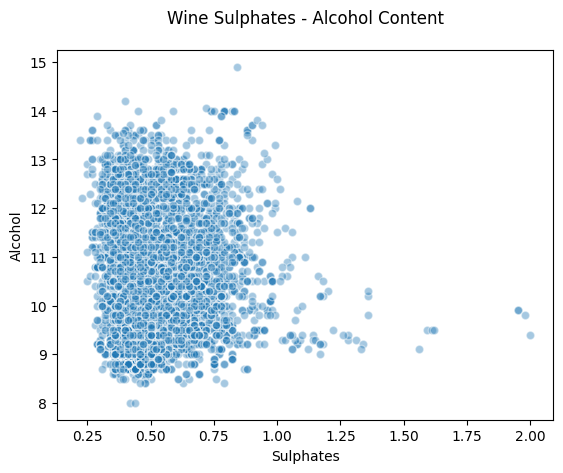

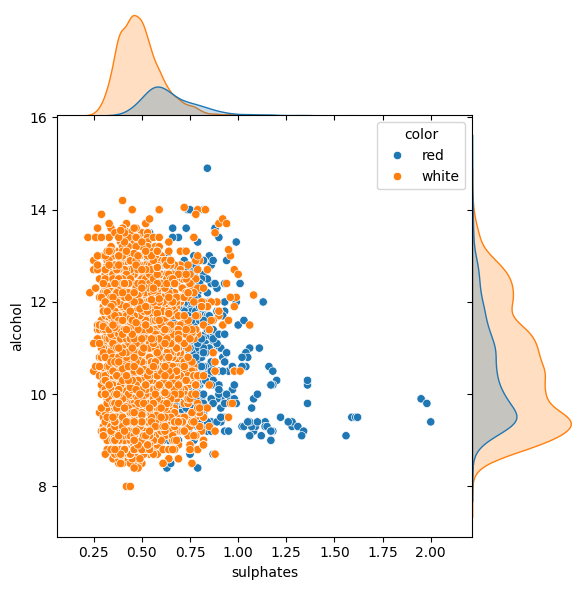

In [10]:
plt.scatter(wines['sulphates'], wines['alcohol'],
            alpha=0.4, edgecolors='w')

plt.xlabel('Sulphates')
plt.ylabel('Alcohol')
plt.title('Wine Sulphates - Alcohol Content', y=1.05)


jp = sns.jointplot(x='sulphates', y='alcohol', data=wines, 
                   hue='color',
                   # kind='reg',
                   space=0, ratio=4)


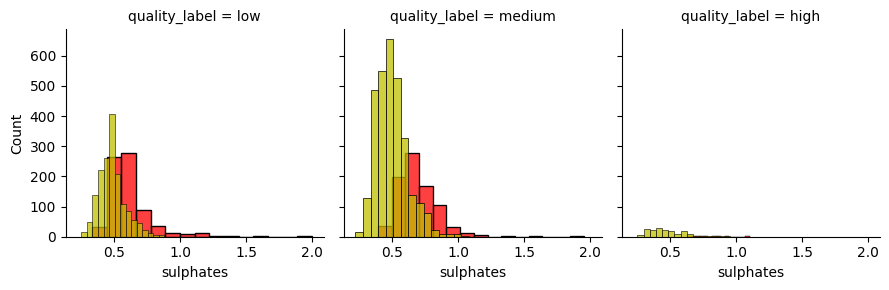

In [11]:
g = sns.FacetGrid(wines, hue='color', palette={"red": "r", "white": "y"}, col='quality_label')
g.map_dataframe(sns.histplot, x='sulphates', kde=False, bins=15)

### box plot

Text(0.5, 0.98, 'Wine Quality - Alcohol Content')

2025-01-10 11:15:02.211 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 11:15:02.220 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quality', ylabel='alcohol'>

Text(0.5, 0, 'Wine Quality')

Text(0, 0.5, 'Wine Alcohol %')

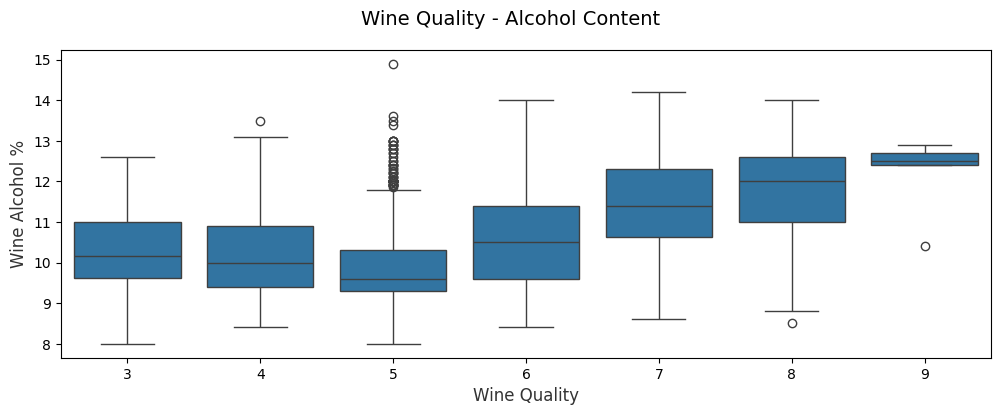

In [12]:
f, (ax) = plt.subplots(1, 1, figsize=(12, 4))
f.suptitle('Wine Quality - Alcohol Content', fontsize=14)

sns.boxplot(x="quality", y="alcohol", data=wines, ax=ax)
ax.set_xlabel("Wine Quality", size = 12, alpha=0.8)
ax.set_ylabel("Wine Alcohol %", size = 12, alpha=0.8)

### Violin Plots

Text(0.5, 0.98, 'Wine Quality - Sulphates Content')

2025-01-10 11:15:02.397 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 11:15:02.405 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quality', ylabel='sulphates'>

Text(0.5, 0, 'Wine Quality')

Text(0, 0.5, 'Wine Sulphates')

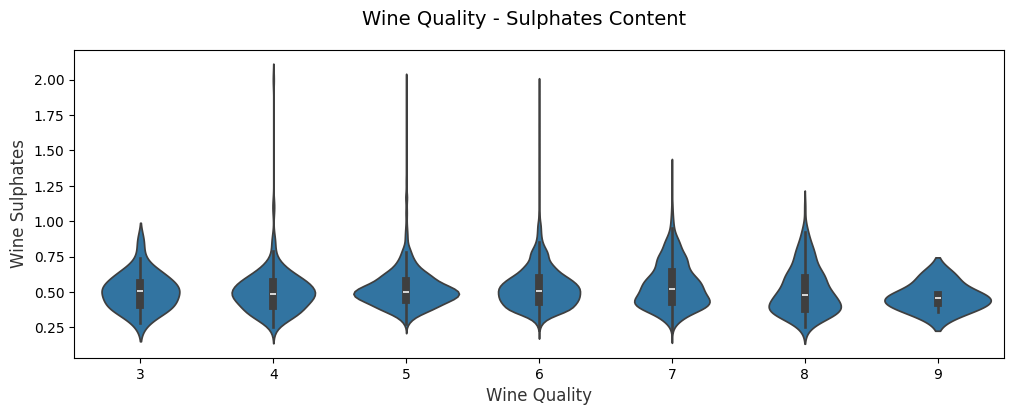

In [13]:
f, (ax) = plt.subplots(1, 1, figsize=(12, 4))
f.suptitle('Wine Quality - Sulphates Content', fontsize=14)

sns.violinplot(x="quality", y="sulphates", data=wines, ax=ax)
ax.set_xlabel("Wine Quality", size = 12, alpha=0.8)
ax.set_ylabel("Wine Sulphates", size = 12, alpha=0.8)

## 三维数据(3-D) 

### 颜色

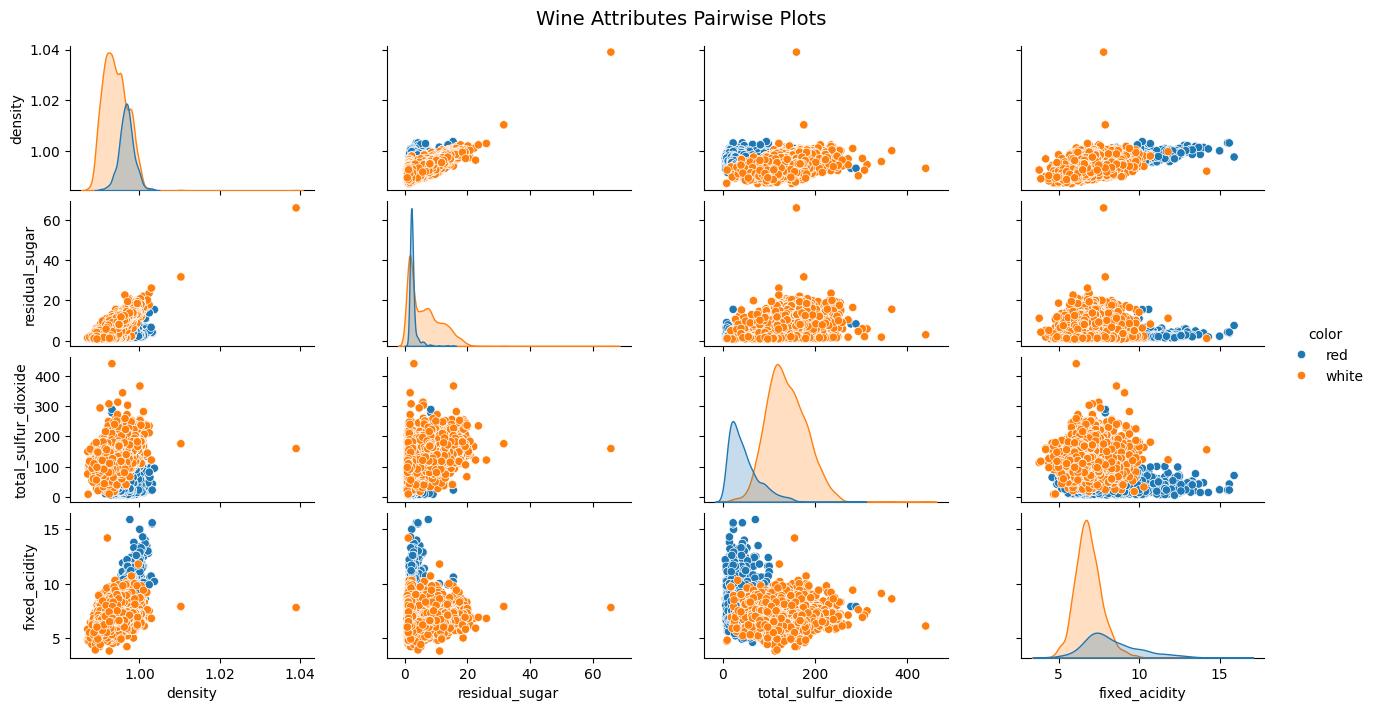

In [14]:
cols = ['density', 'residual_sugar', 'total_sulfur_dioxide', 'fixed_acidity', 'color']
pp = sns.pairplot(wines[cols], hue='color', 
                  height=1.8, aspect=1.8,
                  # diag_kind='hist',
                  # palette={"red": "#FF9999", "white": "#FFE888"},
                  # plot_kws=dict(edgecolor="black", linewidth=0.5)
                 )
fig = pp.fig
fig.subplots_adjust(top=0.93, wspace=0.3)
t = fig.suptitle('Wine Attributes Pairwise Plots', fontsize=14)

### Z轴

Text(0.5, 0, 'Residual Sugar')

Text(0.5, 0.5, 'Fixed Acidity')

Text(0.5, 0, 'Alcohol')

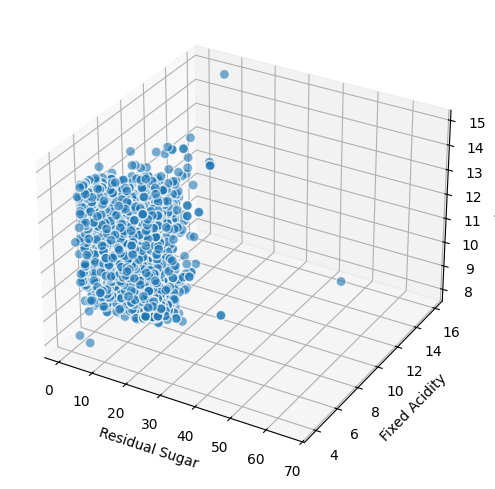

In [15]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

xs = wines['residual_sugar']
ys = wines['fixed_acidity']
zs = wines['alcohol']
cs = wines['color'].map({'red': 1, 'white': 2})

ax.scatter(xs, ys, zs, s=50, alpha=0.6, edgecolors='w')

ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Fixed Acidity')
ax.set_zlabel('Alcohol')

### 尺寸

Text(0.5, 0, 'Fixed Acidity')

Text(0, 0.5, 'Alcohol')

Text(0.5, 1.05, 'Wine Alcohol Content - Fixed Acidity - Residual Sugar')

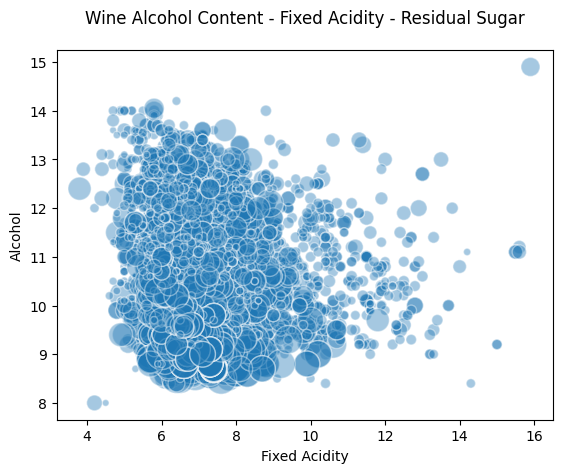

In [19]:
# length, breadth and size
plt.scatter(wines['fixed_acidity'], wines['alcohol'], s=wines['residual_sugar']*25,
            alpha=0.4, edgecolors='w')

plt.xlabel('Fixed Acidity')
plt.ylabel('Alcohol')
plt.title('Wine Alcohol Content - Fixed Acidity - Residual Sugar',y=1.05)

### 多表

2025-01-10 14:14:11.375 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 14:14:11.391 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


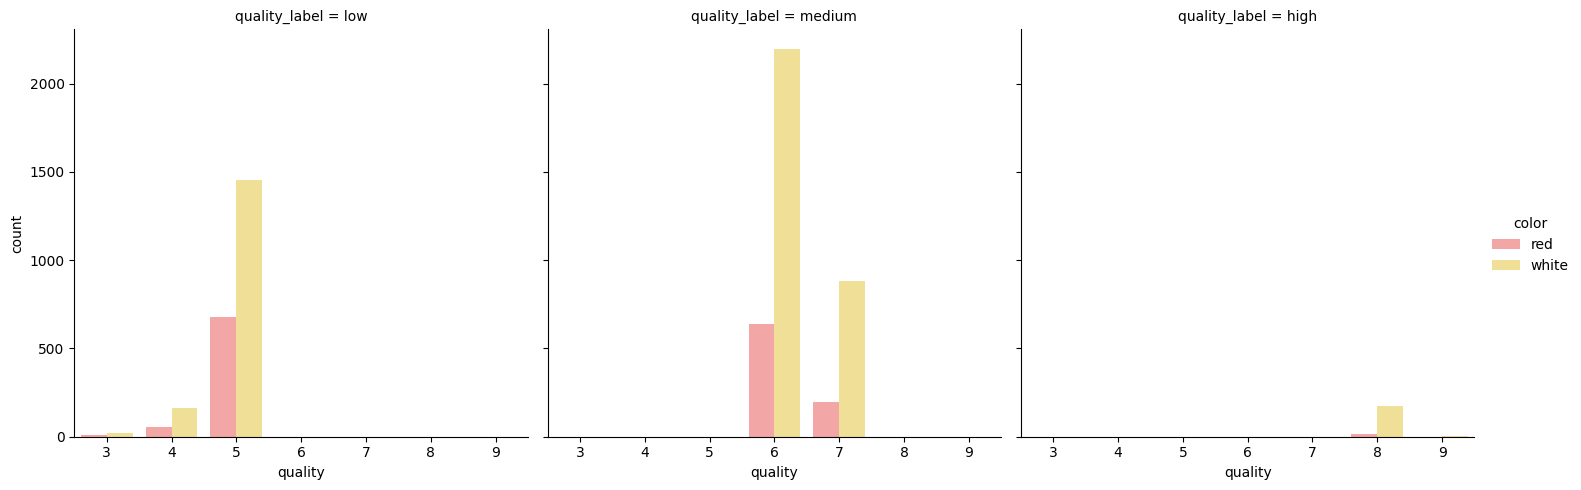

In [33]:
fc = sns.catplot(x="quality", hue="color", col="quality_label",
                    data=wines, kind="count",
                    palette={"red": "#FF9999", "white": "#FFE888"})

### 多分类属性

Text(0.5, 0.98, 'Wine Type - Quality - Acidity')

2025-01-10 14:21:40.361 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 14:21:40.373 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quality', ylabel='volatile_acidity'>

Text(0.5, 0, 'Wine Quality')

Text(0, 0.5, 'Wine Volatile Acidity')

2025-01-10 14:21:40.489 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 14:21:40.498 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quality', ylabel='volatile_acidity'>

Text(0.5, 0, 'Wine Quality')

Text(0, 0.5, 'Wine Volatile Acidity')

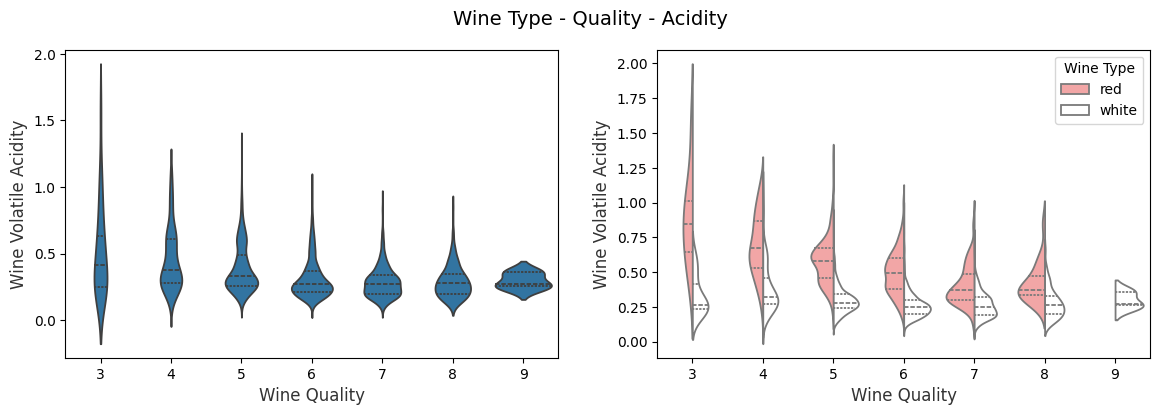

In [43]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Wine Type - Quality - Acidity', fontsize=14)

sns.violinplot(x="quality", y="volatile_acidity",
               data=wines, inner="quart", linewidth=1.3,ax=ax1)
ax1.set_xlabel("Wine Quality",size = 12,alpha=0.8)
ax1.set_ylabel("Wine Volatile Acidity",size = 12,alpha=0.8)

sns.violinplot(x="quality", y="volatile_acidity", hue="color",
               data=wines, split=True, inner="quart", linewidth=1.3,
               palette={"red": "#FF9999", "white": "white"}, ax=ax2)
ax2.set_xlabel("Wine Quality",size = 12,alpha=0.8)
ax2.set_ylabel("Wine Volatile Acidity",size = 12,alpha=0.8)
l = plt.legend(loc='upper right', title='Wine Type')

Text(0.5, 0.98, 'Wine Type - Quality - Alcohol Content')

2025-01-10 14:23:29.609 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-10 14:23:29.623 - MainThread - matplotlib.category - INFO - category.py - 223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='quality', ylabel='alcohol'>

Text(0.5, 0, 'Wine Quality')

Text(0, 0.5, 'Wine Alcohol %')

<Axes: xlabel='quality_label', ylabel='alcohol'>

Text(0.5, 0, 'Wine Quality Class')

Text(0, 0.5, 'Wine Alcohol %')

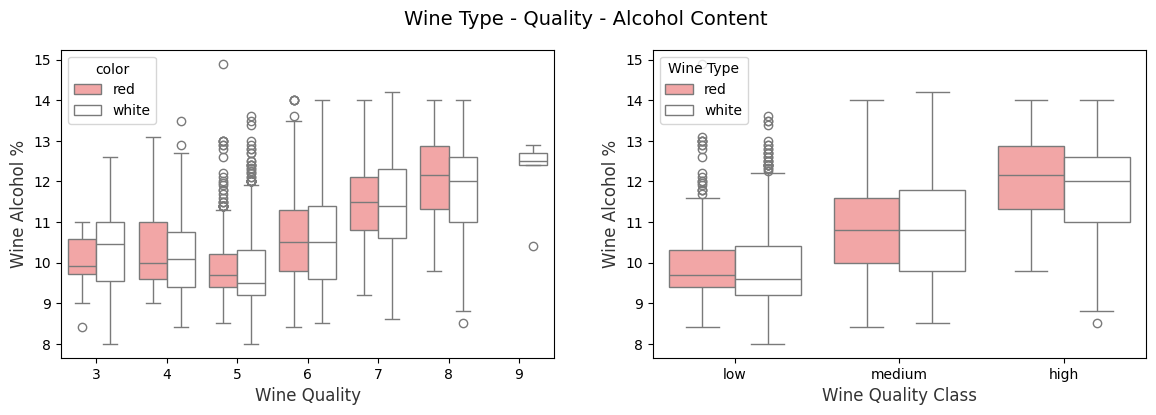

In [44]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Wine Type - Quality - Alcohol Content', fontsize=14)

sns.boxplot(x="quality", y="alcohol", hue="color",
               data=wines, palette={"red": "#FF9999", "white": "white"}, ax=ax1)
ax1.set_xlabel("Wine Quality",size = 12,alpha=0.8)
ax1.set_ylabel("Wine Alcohol %",size = 12,alpha=0.8)

sns.boxplot(x="quality_label", y="alcohol", hue="color",
               data=wines, palette={"red": "#FF9999", "white": "white"}, ax=ax2)
ax2.set_xlabel("Wine Quality Class",size = 12,alpha=0.8)
ax2.set_ylabel("Wine Alcohol %",size = 12,alpha=0.8)
l = plt.legend(loc='best', title='Wine Type')

### 其他

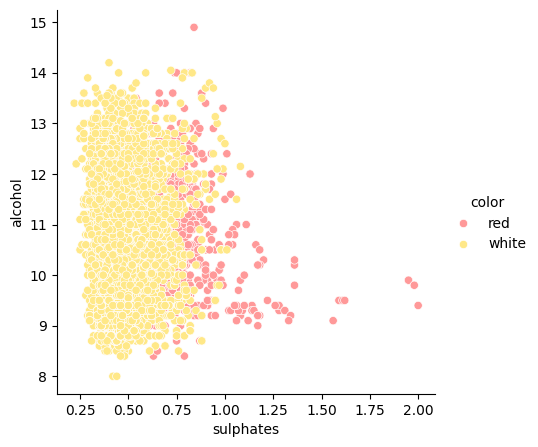

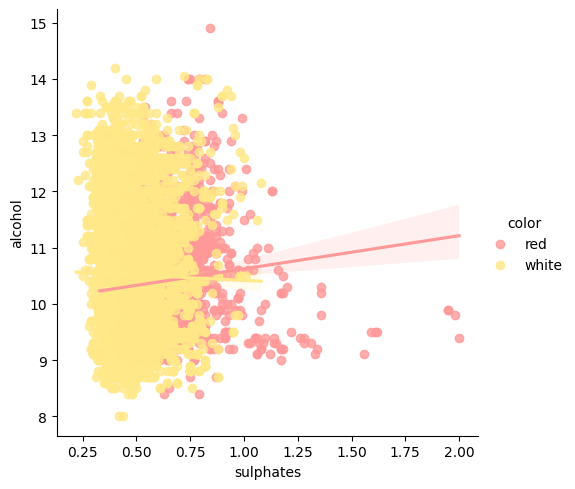

In [41]:
jp = sns.pairplot(wines, x_vars=["sulphates"], y_vars=["alcohol"], height=4.5,
                  hue="color", palette={"red": "#FF9999", "white": "#FFE888"})

lp = sns.lmplot(x='sulphates', y='alcohol', hue='color',
                palette={"red": "#FF9999", "white": "#FFE888"},
                data=wines, fit_reg=True, legend=True)

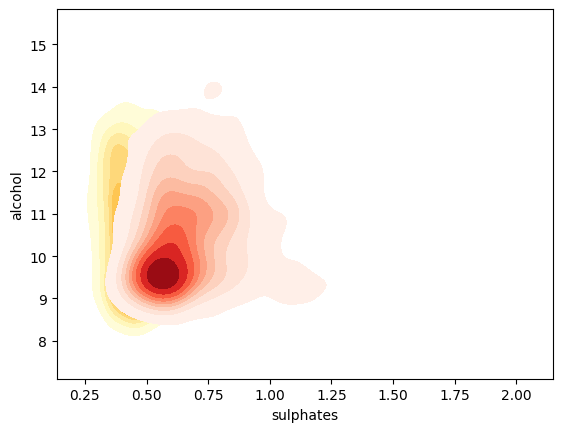

In [42]:
white_wine = wines[wines.color=='white']
red_wine = wines[wines.color=='red']
ax = sns.kdeplot(data=white_wine, x='sulphates', y='alcohol',
                  cmap="YlOrBr", fill=True, thresh=0.05)
ax = sns.kdeplot(data=red_wine, x='sulphates', y='alcohol',
                  cmap="Reds", fill=True, thresh=0.05)

## 四维数据（4-D）
+ 在传统图如散点图中利用深度和色调表征特定的数据维度
+ 使用二维图，但利用色调和数据点大小作为数据维度。

Text(0.5, 0, 'Residual Sugar')

Text(0.5, 0.5, 'Alcohol')

Text(0.5, 0, 'Fixed Acidity')

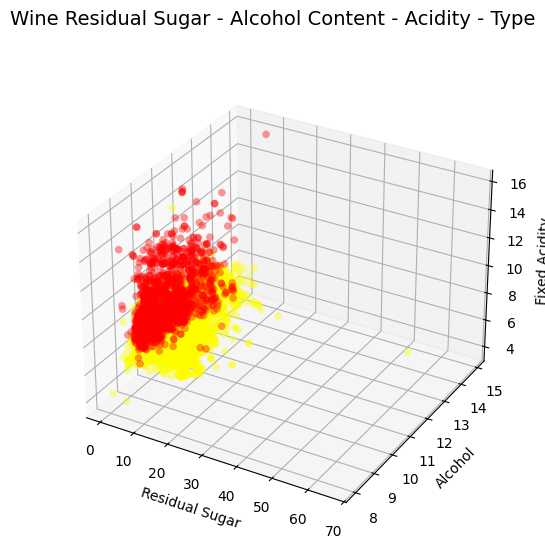

In [53]:
# 在传统图如散点图中利用深度和色调表征特定的数据维度
fig = plt.figure(figsize=(8, 6))
t = fig.suptitle('Wine Residual Sugar - Alcohol Content - Acidity - Type', fontsize=14)
ax = fig.add_subplot(111, projection='3d')

for color in ['red', 'white']:
    _wines = wines[wines.color==color]
    color = 'yellow' if color == 'white' else color
    x, y, z = _wines['residual_sugar'].tolist(), _wines['alcohol'].tolist(), _wines['fixed_acidity'].tolist()
    ax.scatter(x, y, z, alpha=0.4, c=color, edgecolors='none', s=30)

ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Alcohol')
ax.set_zlabel('Fixed Acidity')

Text(0.5, 0, 'Fixed Acidity')

Text(0, 0.5, 'Alcohol')

Text(0.5, 1.05, 'Wine Alcohol Content - Fixed Acidity - Residual Sugar - Type')

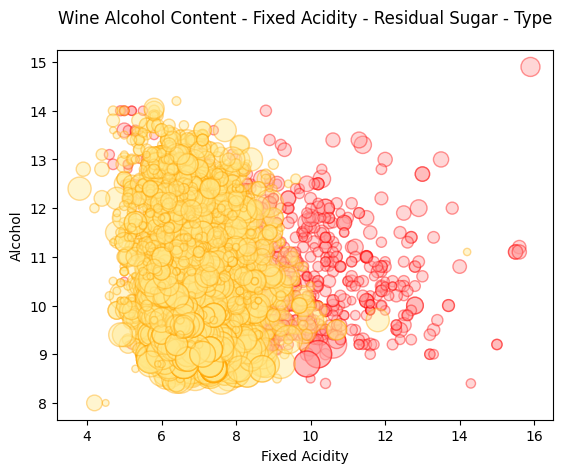

In [56]:
# 使用二维图，但利用色调和数据点大小作为数据维度
size = wines['residual_sugar'] * 25
fill_colors = ['#FF9999' if wt=='red' else '#FFE888' for wt in list(wines['color'])]
edge_colors = ['red' if wt=='red' else 'orange' for wt in list(wines['color'])]

plt.scatter(wines['fixed_acidity'], wines['alcohol'], s=size,
            alpha=0.4, color=fill_colors, edgecolors=edge_colors)

plt.xlabel('Fixed Acidity')
plt.ylabel('Alcohol')
plt.title('Wine Alcohol Content - Fixed Acidity - Residual Sugar - Type',y=1.05)

Text(0.5, 0.98, 'Wine Type - Alcohol - Quality - Acidity')

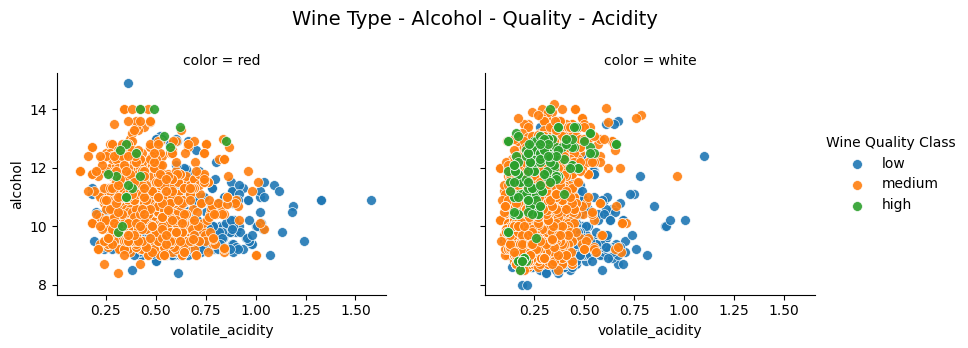

In [67]:
# 通过利用散点图以及色调和分面的概念可视化 4 维数据
g = sns.FacetGrid(wines, col="color", hue='quality_label',
                  col_order=['red', 'white'], hue_order=['low', 'medium', 'high'],
                  aspect=1.2, height=3.5,
                  # palette=sns.light_palette('navy', 4)[1:]
                 )
g.map(plt.scatter, "volatile_acidity", "alcohol", alpha=0.9,
      edgecolor='white', linewidth=0.5, s=50)
fig = g.fig
fig.subplots_adjust(top=0.8, wspace=0.3)
fig.suptitle('Wine Type - Alcohol - Quality - Acidity', fontsize=14)
l = g.add_legend(title='Wine Quality Class')

## 五维数据（5-D） 
+ 使用深度、色调、大小来表征其中的三个维度

Text(0.5, 0, 'Residual Sugar')

Text(0.5, 0.5, 'Alcohol')

Text(0.5, 0, 'Fixed Acidity')

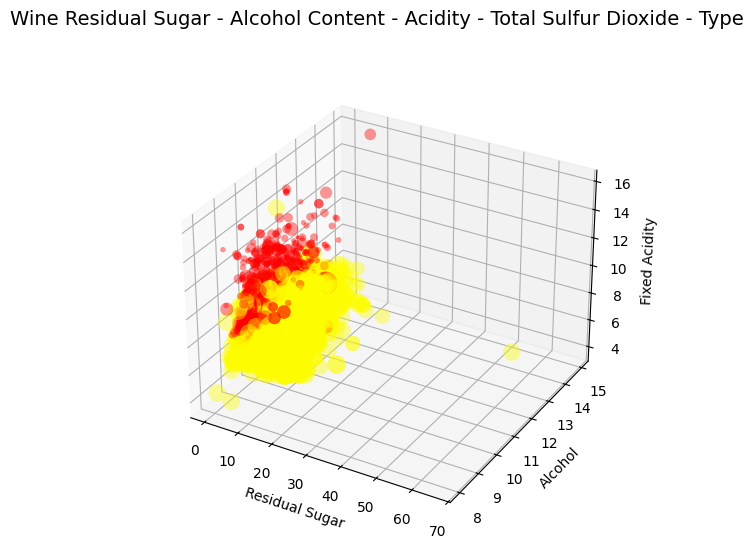

In [68]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
t = fig.suptitle('Wine Residual Sugar - Alcohol Content - Acidity - Total Sulfur Dioxide - Type', fontsize=14)

xs = list(wines['residual_sugar'])
ys = list(wines['alcohol'])
zs = list(wines['fixed_acidity'])
data_points = [(x, y, z) for x, y, z in zip(xs, ys, zs)]

ss = list(wines['total_sulfur_dioxide'])
colors = ['red' if wt == 'red' else 'yellow' for wt in list(wines['color'])]

for data, color, size in zip(data_points, colors, ss):
    x, y, z = data
    a = ax.scatter(x, y, z, alpha=0.4, c=color, edgecolors='none', s=size)

ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Alcohol')
ax.set_zlabel('Fixed Acidity')

In [90]:
from pyecharts import options as opts
from pyecharts.charts import Scatter3D
import pandas as pd

# 假设 wines 数据集已经加载
# wines = pd.read_csv("wines.csv")  # 示例，加载数据

# 数据处理
xs = list(wines['residual_sugar'])
ys = list(wines['alcohol'])
zs = list(wines['fixed_acidity'])
ss = list(wines['total_sulfur_dioxide'])  # 用于控制点大小
colors = [1 if wt == 'red' else 2 for wt in wines['color']]  # 红色或黄色

# 将数据整合为 Scatter3D 所需的格式
data = [[x, y, z, size, color] for x, y, z, size, color in zip(xs, ys, zs, ss, colors)]

# 创建 3D 散点图
scatter = (
    Scatter3D()
    .add(
        series_name="Wine Data",
        data=data,  # 数据点
        # 设置坐标轴
        xaxis3d_opts=opts.Axis3DOpts(
            type_="value", name="Residual Sugar", name_gap=10
        ),
        yaxis3d_opts=opts.Axis3DOpts(
            type_="value", name="Alcohol", name_gap=10
        ),
        zaxis3d_opts=opts.Axis3DOpts(
            type_="value", name="Fixed Acidity", name_gap=10
        ),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(title="Wine Residual Sugar - Alcohol Content - Acidity"),
        visualmap_opts=[
            opts.VisualMapOpts(
                type_="color",  # 颜色映射
                is_calculable=True,
                dimension=4,  # 使用数据中的第 5 维 (color) 控制颜色
                range_color=['#FF0000', '#FFFF00'],  # 红色和黄色映射
                max_=max(colors),
                pos_top="10%",
            ),
            opts.VisualMapOpts(
                type_="size",  # 点大小映射
                is_calculable=True,
                dimension=3,  # 使用数据中的第 4 维 (size) 控制大小
                max_=max(ss),  # 根据 'total_sulfur_dioxide' 最大值调整范围
                range_size=[10, 40],  # 设置大小范围
                pos_bottom="10%",
            ),
        ],
        tooltip_opts=opts.TooltipOpts(
            formatter=JsCode("""function(params) {
                return 'Residual Sugar: ' + params.value[0] + '<br>' +
                       'Alcohol: ' + params.value[1] + '<br>' +
                       'Fixed Acidity: ' + params.value[2] + '<br>' +
                       'Total Sulfur Dioxide: ' + params.value[3] + '<br>' +
                       'Color: ' + (params.value[4] === 1 ? 'Red' : 'Yellow');
            }""")
        ),
    )
)

# 渲染图形
scatter.load_javascript()
scatter.render_notebook()


## 六维数据（6-D） 
+ 利用深度、色调、大小和形状及两个常规轴来描述所有 6 个数据维度

C:\Users\HQ\AppData\Local\Temp\ipykernel_20208\2520378912.py:16: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  a = ax.scatter(x, y, z, alpha=0.4, c=color, edgecolors='none', s=size, marker=mark)


Text(0.5, 0, 'Residual Sugar')

Text(0.5, 0.5, 'Alcohol')

Text(0.5, 0, 'Fixed Acidity')

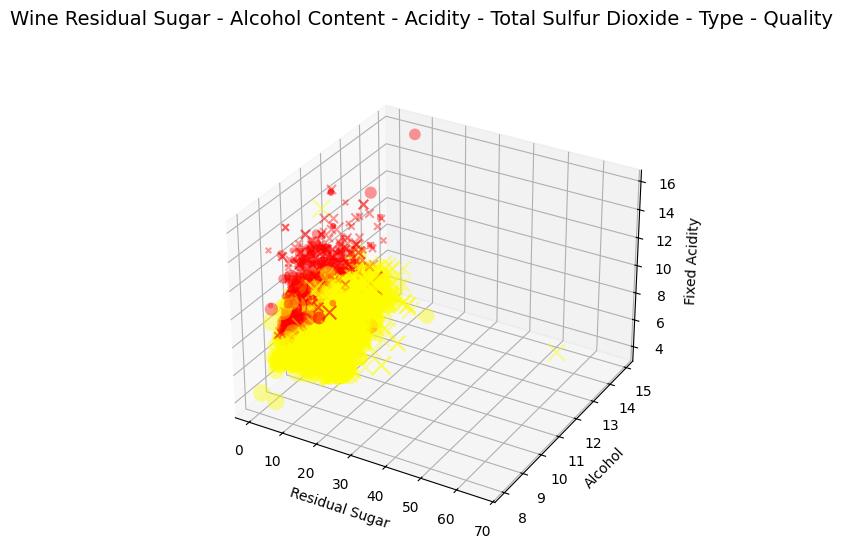

In [92]:
fig = plt.figure(figsize=(8, 6))
t = fig.suptitle('Wine Residual Sugar - Alcohol Content - Acidity - Total Sulfur Dioxide - Type - Quality', fontsize=14)
ax = fig.add_subplot(111, projection='3d')

xs = list(wines['residual_sugar'])
ys = list(wines['alcohol'])
zs = list(wines['fixed_acidity'])
data_points = [(x, y, z) for x, y, z in zip(xs, ys, zs)]

ss = list(wines['total_sulfur_dioxide'])
colors = ['red' if wt == 'red' else 'yellow' for wt in list(wines['color'])]
markers = [',' if q == 'high' else 'x' if q == 'medium' else 'o' for q in list(wines['quality_label'])]

for data, color, size, mark in zip(data_points, colors, ss, markers):
    x, y, z = data
    a = ax.scatter(x, y, z, alpha=0.4, c=color, edgecolors='none', s=size, marker=mark)

ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Alcohol')
ax.set_zlabel('Fixed Acidity')

In [96]:
from pyecharts import options as opts
from pyecharts.charts import Scatter3D
from pyecharts.commons.utils import JsCode

# 假设 wines 数据集已经加载
# wines = pd.read_csv("wines.csv")  # 示例，加载数据

# 数据处理
xs = list(wines['residual_sugar'])
ys = list(wines['alcohol'])
zs = list(wines['fixed_acidity'])
ss = list(wines['total_sulfur_dioxide'])  # 点大小
quality_labels = list(wines['quality_label'])  # 'high', 'medium', 'low'

# 为每个类别分配一个数值
quality_mapping = {'high': 3, 'medium': 2, 'low': 1}
qualities = [quality_mapping[q] for q in quality_labels]

# 整理数据为 Scatter3D 所需格式
data = [[x, y, z, size, quality] for x, y, z, size, quality in zip(xs, ys, zs, ss, qualities)]

# 创建 3D 散点图
scatter = (
    Scatter3D()
    .add(
        series_name="Wine Data",
        data=data,
        xaxis3d_opts=opts.Axis3DOpts(type_="value", name="Residual Sugar"),
        yaxis3d_opts=opts.Axis3DOpts(type_="value", name="Alcohol"),
        zaxis3d_opts=opts.Axis3DOpts(type_="value", name="Fixed Acidity"),
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(title="Wine Residual Sugar - Alcohol - Acidity - Quality"),
        visualmap_opts=[
            opts.VisualMapOpts(
                type_="color",
                is_calculable=True,
                dimension=4,  # 使用数据中的第五维 (quality) 控制颜色
                range_color=["#32CD32", "#FF8C00", "#0000FF"],  # 低、中、高分别对应绿、橙、蓝
                max_=3,
                pos_top="10%",
            ),
            opts.VisualMapOpts(
                type_="size",
                is_calculable=True,
                dimension=3,  # 使用数据中的第四维 (size) 控制大小
                max_=max(ss),
                range_size=[10, 40],
                pos_bottom="10%",
            ),
        ],
        tooltip_opts=opts.TooltipOpts(
            formatter=JsCode(
                """
                function (params) {
                    var quality_map = {1: 'Low', 2: 'Medium', 3: 'High'};
                    return 'Residual Sugar: ' + params.value[0] + '<br>' +
                           'Alcohol: ' + params.value[1] + '<br>' +
                           'Fixed Acidity: ' + params.value[2] + '<br>' +
                           'Total Sulfur Dioxide: ' + params.value[3] + '<br>' +
                           'Quality: ' + quality_map[params.value[4]];
                }
                """
            )
        ),
    )
)

# 渲染图形
scatter.load_javascript()
scatter.render_notebook()


ValueError: s must be a scalar, or float array-like with the same size as x and y

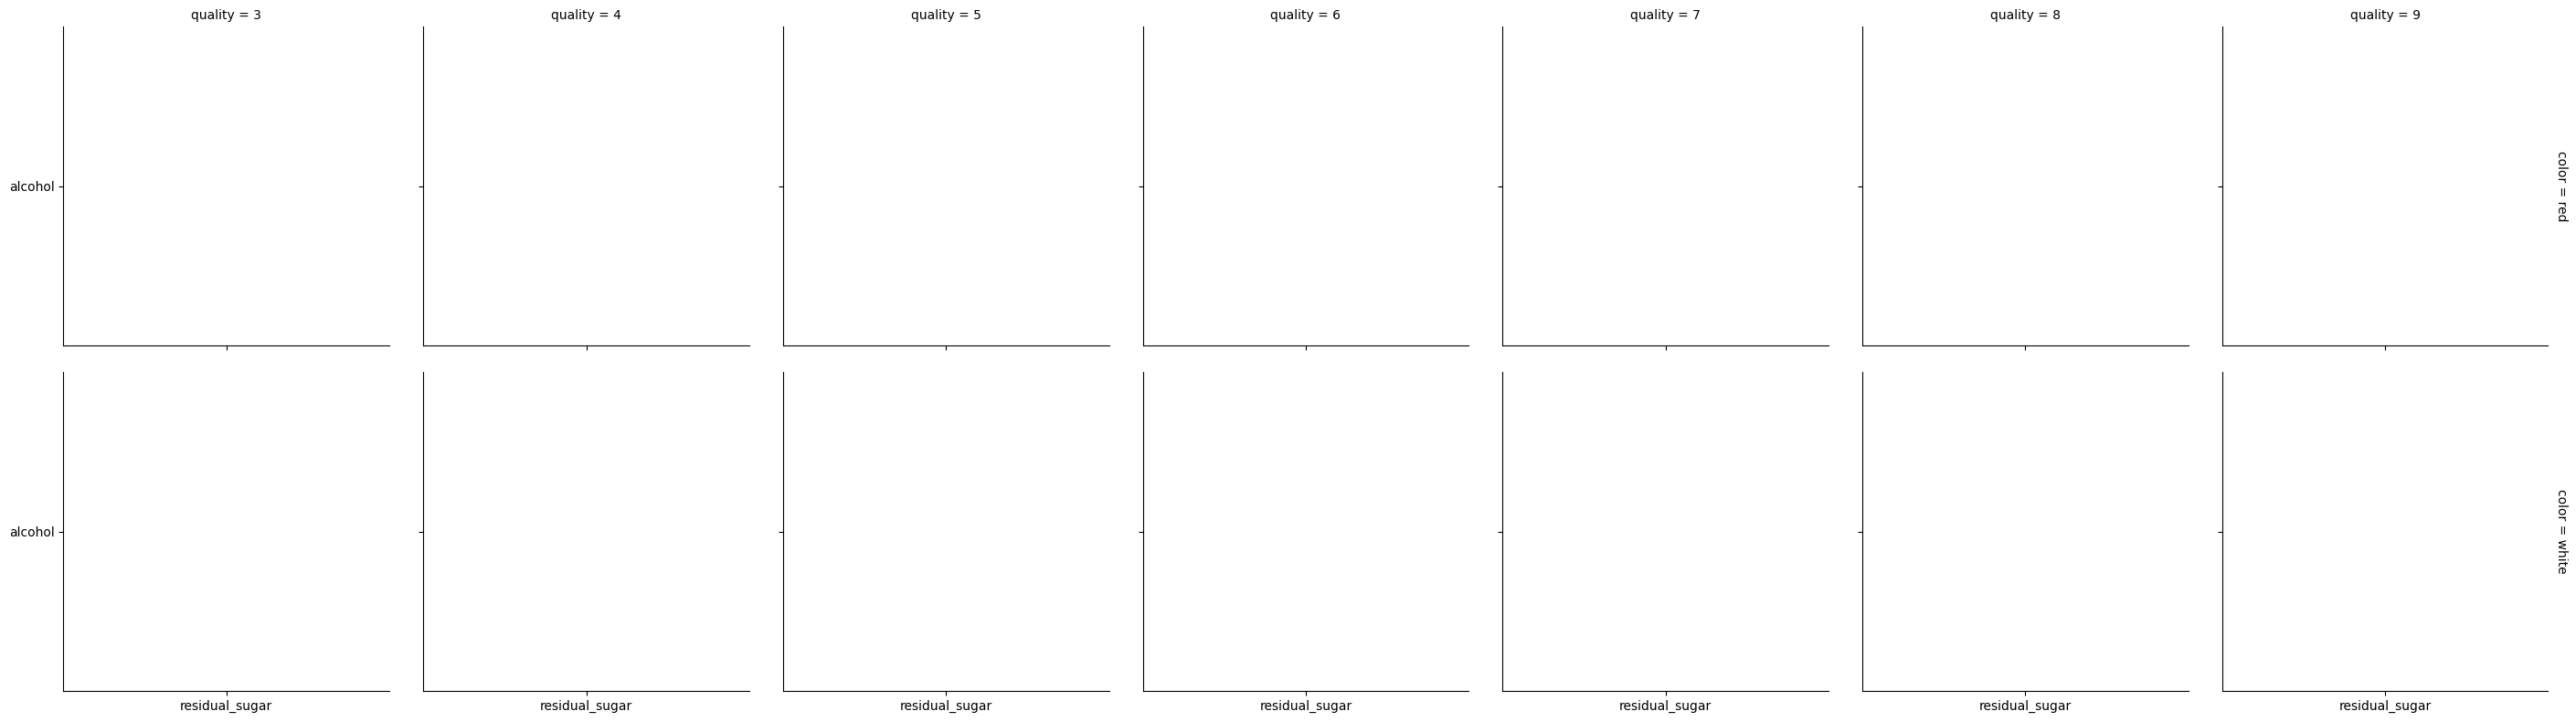

In [130]:
# 定义一个绘图函数，动态匹配 s 的大小
def scatter_plot(x, y, **kwargs):
    data = kwargs.pop("data")  # 提取分组数据
    sizes = data['scaled_size'].values * 100  # 根据分组数据调整点大小
    # print("数据长度检查:", len(data[x]), len(data[y]), len(sizes))
    plt.scatter(x, y, alpha=0.5, edgecolor='k', linewidth=0.5, s=sizes, **kwargs)

# 确保 'scaled_size' 是 wines 中的一列（归一化处理）
wines['scaled_size'] = wines['total_sulfur_dioxide'] / wines['total_sulfur_dioxide'].max() * 100
wines['scaled_size'] = wines['scaled_size'].fillna('0.0')

# 创建 FacetGrid
g = sns.FacetGrid(
    wines,
    row='color',
    col="quality",
    hue='quality_label',
    height=4,
    margin_titles=True
)

# 使用自定义绘图函数
g.map_dataframe(scatter_plot, "residual_sugar", "alcohol")

# 调整整体布局
fig = g.fig
fig.set_size_inches(24, 8)
fig.subplots_adjust(top=0.9)
fig.suptitle('Residual Sugar vs Alcohol by Quality and Color', fontsize=16)
